# Análisis Exploratorio de Datos sobre Precios de Cadenas de Supermercados en Uruguay

Este notebook presenta un análisis exploratorio de datos aplicado a una base comercial de precios de cadenas de supermercados en Uruguay durante el año 2025.

El objetivo principal es estudiar el comportamiento de los precios según distintos establecimientos, grupos de productos y períodos disponibles en la base de datos.

## Paso 1: Definición del problema

El problema que se busca analizar es cómo varían los precios de productos relevados en distintas cadenas comerciales de Uruguay durante el año 2025.

El dataset contiene información sobre productos, grupos comerciales, supermercados, períodos y precios. A partir de estos datos, se busca responder preguntas como:

- ¿Qué supermercados tienen mayor cantidad de registros en la base?
- ¿Qué grupos de productos aparecen con mayor frecuencia?
- ¿Cómo se distribuyen los precios?
- ¿Existen diferencias relevantes de precios entre supermercados?
- ¿Qué grupos de productos presentan precios promedio más altos?
- ¿Los valores extremos deben eliminarse o pueden interpretarse dentro del contexto comercial?

Este análisis permitirá comprender mejor la estructura del dataset y preparar una base sólida para la posterior construcción de visualizaciones interactivas.

## Objetivo del análisis

El objetivo del análisis es realizar una exploración inicial del dataset para identificar patrones, distribuciones y posibles relaciones entre las variables principales.

La variable numérica principal del trabajo es `Precio`, mientras que las variables categóricas más relevantes son `Super`, `Grupo`, `Producto` y `Periodo`.

El enfoque será descriptivo y comercial. No se busca predecir precios, sino entender cómo se comportan dentro de la base de datos y qué información útil se puede extraer para la toma de decisiones.

In [1]:
# PASO 2: IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# PASO 3: CARGA DEL DATASET

# Ruta local del archivo CSV dentro del entorno de trabajo
ruta = r"C:\Users\aleva\OneDrive\Escritorio\Alexia\pyhton\data\raw\p4ds_cadenas_unificadas_2025.csv"

# Cargamos el archivo en un DataFrame de pandas
datos_cadena = pd.read_csv(ruta)

# Mostramos las primeras filas para verificar que la carga fue correcta
datos_cadena.head()

,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,"80,00"
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,"99,00"
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,"99,00"
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,"95,00"
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,"97,00"


In [3]:
# PASO 4: EXPLORACIÓN INICIAL DEL DATASET

print("Dimensiones del dataset original:")
print(datos_cadena.shape)
print("-" * 50)

print("Primeras filas del dataset:")
display(datos_cadena.head())
print("-" * 50)

print("Información general de las columnas:")
datos_cadena.info()
print("-" * 50)

print("Cantidad de valores nulos por columna:")
print(datos_cadena.isnull().sum())
print("-" * 50)

print("Resumen descriptivo inicial:")
display(datos_cadena.describe(include="all").T)

Dimensiones del dataset original:
(26834, 5)
--------------------------------------------------
Primeras filas del dataset:


,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,"80,00"
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,"99,00"
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,"99,00"
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,"95,00"
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,"97,00"


--------------------------------------------------
Información general de las columnas:
<class 'pandas.DataFrame'>
RangeIndex: 26834 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   26834 non-null  str  
 1   Grupo     26671 non-null  str  
 2   Producto  26812 non-null  str  
 3   Super     24237 non-null  str  
 4   Precio    26401 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB
--------------------------------------------------
Cantidad de valores nulos por columna:
Periodo        0
Grupo        163
Producto      22
Super       2597
Precio       433
dtype: int64
--------------------------------------------------
Resumen descriptivo inicial:


,count,unique,top,freq
Periodo,26834,12,Dic25,2333
Grupo,26671,10,Alimentos y bebidas,13261
Producto,26812,427,"Jabón de tocador Dove Blanco, 90 grs.",209
Super,24237,17,Red Expres,2260
Precio,26401,2234,"75,00",334


## Paso 4: Exploración inicial del dataset

En la exploración inicial se revisan las dimensiones de la base, los nombres de las columnas, los tipos de datos y la cantidad de valores nulos.

El dataset contiene información sobre:

- `Periodo`: mes o período del relevamiento.
- `Grupo`: categoría comercial del producto.
- `Producto`: nombre del producto relevado.
- `Super`: cadena o establecimiento donde fue registrado.
- `Precio`: precio del producto.

En esta etapa se detecta que la columna `Precio` aparece como texto y no como número. Esto ocurre porque los precios utilizan coma decimal, por ejemplo `80,00`, formato que Python no interpreta automáticamente como valor numérico.

Por lo tanto, antes de realizar gráficos o cálculos estadísticos, será necesario limpiar y convertir esta columna.

In [4]:
# PASO 5: LIMPIEZA Y TRATAMIENTO DE DATOS

# Creamos una copia del dataset original para trabajar la limpieza
datos_limpios = datos_cadena.copy()

# ---------------------------------------------------------------------
# 5.1 Conversión de la columna Precio
# ---------------------------------------------------------------------

# Convertimos Precio a texto para poder reemplazar la coma decimal
datos_limpios["Precio"] = datos_limpios["Precio"].astype(str)

# Reemplazamos coma decimal por punto decimal
datos_limpios["Precio"] = datos_limpios["Precio"].str.replace(",", ".", regex=False)

# Convertimos Precio a valor numérico
datos_limpios["Precio"] = pd.to_numeric(datos_limpios["Precio"], errors="coerce")

# ---------------------------------------------------------------------
# 5.2 Tratamiento de valores nulos
# ---------------------------------------------------------------------

# Eliminamos filas sin precio válido, ya que Precio es la variable principal del análisis
datos_limpios = datos_limpios.dropna(subset=["Precio"]).copy()

# Rellenamos valores nulos en variables categóricas
datos_limpios["Grupo"] = datos_limpios["Grupo"].fillna("Desconocido")
datos_limpios["Producto"] = datos_limpios["Producto"].fillna("Desconocido")
datos_limpios["Super"] = datos_limpios["Super"].fillna("Desconocido")

# ---------------------------------------------------------------------
# 5.3 Verificación final
# ---------------------------------------------------------------------

print("Dimensiones del dataset luego de la limpieza:")
print(datos_limpios.shape)
print("-" * 50)

print("Tipos de datos luego de la limpieza:")
print(datos_limpios.dtypes)
print("-" * 50)

print("Valores nulos luego de la limpieza:")
print(datos_limpios.isnull().sum())
print("-" * 50)

print("Resumen estadístico de Precio:")
display(datos_limpios["Precio"].describe().round(2))

Dimensiones del dataset luego de la limpieza:
(25897, 5)
--------------------------------------------------
Tipos de datos luego de la limpieza:
Periodo         str
Grupo           str
Producto        str
Super           str
Precio      float64
dtype: object
--------------------------------------------------
Valores nulos luego de la limpieza:
Periodo     0
Grupo       0
Producto    0
Super       0
Precio      0
dtype: int64
--------------------------------------------------
Resumen estadístico de Precio:


count    25897.00
mean       238.65
std        504.41
min          6.00
25%         75.00
50%        129.00
75%        249.00
max      25800.00
Name: Precio, dtype: float64

In [5]:
# 5.4 RESUMEN FINAL DE LA LIMPIEZA

filas_originales = datos_cadena.shape[0]
columnas_originales = datos_cadena.shape[1]

filas_limpias = datos_limpios.shape[0]
columnas_limpias = datos_limpios.shape[1]

filas_eliminadas = filas_originales - filas_limpias

print("RESUMEN FINAL DE LA LIMPIEZA")
print("-" * 50)
print(f"Filas originales: {filas_originales}")
print(f"Columnas originales: {columnas_originales}")
print(f"Filas luego de la limpieza: {filas_limpias}")
print(f"Columnas luego de la limpieza: {columnas_limpias}")
print(f"Filas eliminadas: {filas_eliminadas}")
print("-" * 50)
print("Valores nulos luego de la limpieza:")
print(datos_limpios.isnull().sum())

RESUMEN FINAL DE LA LIMPIEZA
--------------------------------------------------
Filas originales: 26834
Columnas originales: 5
Filas luego de la limpieza: 25897
Columnas luego de la limpieza: 5
Filas eliminadas: 937
--------------------------------------------------
Valores nulos luego de la limpieza:
Periodo     0
Grupo       0
Producto    0
Super       0
Precio      0
dtype: int64


### Conclusión del Paso 5

Luego del proceso de limpieza, el dataset pasó de tener 26.834 filas y 5 columnas a tener 25.897 filas y 5 columnas.

Se eliminaron 937 registros porque no tenían un precio válido. Esta decisión es adecuada porque `Precio` es la variable principal del análisis y no conviene reemplazarla por valores inventados.

Las columnas categóricas `Grupo`, `Producto` y `Super` fueron completadas con el valor `"Desconocido"` en los casos donde tenían datos faltantes. De esta manera, se conservan registros útiles sin perder información numérica relevante.

Al finalizar la limpieza, el dataset queda sin valores nulos y con la columna `Precio` convertida correctamente a formato numérico. A partir de este punto, el análisis exploratorio se realizará sobre el DataFrame `datos_limpios`.

## Paso 5: Limpieza y tratamiento de datos

En esta etapa se realiza la limpieza necesaria para poder analizar correctamente el dataset.

La transformación más importante es la conversión de la columna `Precio` a formato numérico. Originalmente, los precios aparecen con coma decimal, por lo que se reemplaza la coma por un punto y luego se aplica `pd.to_numeric()`.

También se eliminan los registros sin precio válido, ya que `Precio` es la variable principal del análisis. En cambio, los valores faltantes en variables categóricas como `Super`, `Grupo` y `Producto` se reemplazan por el valor `"Desconocido"`.

Esta decisión permite conservar registros útiles sin inventar información numérica.

## Paso 6: Análisis univariante

En este paso se realiza un análisis univariante, es decir, se estudia cada variable de forma individual.

El objetivo es comprender la distribución y frecuencia de las principales variables del dataset antes de analizar relaciones entre ellas.

Para este trabajo se analizarán:

- `Super`: cadena o establecimiento donde se registró el producto.
- `Grupo`: categoría o rubro comercial del producto.
- `Precio`: variable numérica principal del análisis.

Este análisis permite conocer la composición general de la base y detectar patrones iniciales en los datos.

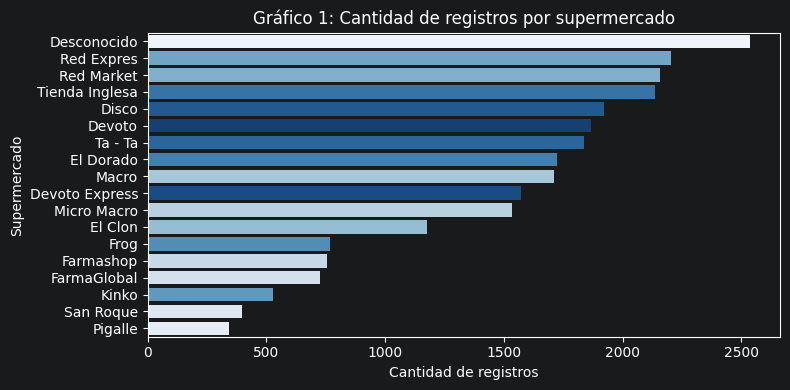

Cantidad de registros por supermercado:
Super
Desconocido       2536
Red Expres        2205
Red Market        2158
Tienda Inglesa    2137
Disco             1921
Devoto            1868
Ta - Ta           1839
El Dorado         1723
Macro             1713
Devoto Express    1570
Micro Macro       1534
El Clon           1174
Frog               769
Farmashop          755
FarmaGlobal        727
Kinko              527
San Roque          398
Pigalle            343
Name: count, dtype: int64


In [6]:
# PASO 6: ANÁLISIS UNIVARIANTE

# 6.1 DISTRIBUCIÓN POR SUPERMERCADO

plt.figure(figsize=(8, 4))

sns.countplot(
    data=datos_limpios,
    y="Super",
    order=datos_limpios["Super"].value_counts().index,
    hue="Super",
    palette="Blues_r",
    legend=False
)

plt.title("Gráfico 1: Cantidad de registros por supermercado")
plt.xlabel("Cantidad de registros")
plt.ylabel("Supermercado")
plt.tight_layout()
plt.show()

print("Cantidad de registros por supermercado:")
print(datos_limpios["Super"].value_counts())

### Interpretación de la variable Super

El gráfico muestra la cantidad de registros disponibles para cada supermercado o establecimiento.

Esta información es importante porque permite identificar si la base está equilibrada entre cadenas o si algunos supermercados tienen mayor representación que otros.

Una mayor cantidad de registros no significa necesariamente que un supermercado sea más grande o más barato, sino que dentro del dataset hay más observaciones disponibles para esa cadena.

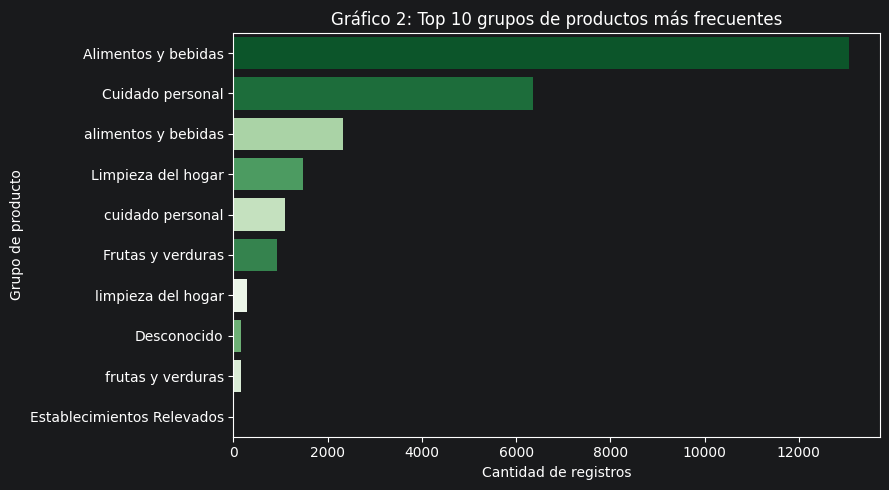

Top 10 grupos de productos más frecuentes:
Grupo
Alimentos y bebidas           13071
Cuidado personal               6361
alimentos y bebidas            2334
Limpieza del hogar             1484
cuidado personal               1092
Frutas y verduras               919
limpieza del hogar              280
Desconocido                     159
frutas y verduras               157
Establecimientos Relevados       22
Name: count, dtype: int64


In [7]:
# 6.2 DISTRIBUCIÓN POR GRUPO DE PRODUCTO

top_grupos = datos_limpios["Grupo"].value_counts().head(10).index

plt.figure(figsize=(9, 5))

sns.countplot(
    data=datos_limpios[datos_limpios["Grupo"].isin(top_grupos)],
    y="Grupo",
    order=top_grupos,
    hue="Grupo",
    palette="Greens_r",
    legend=False
)

plt.title("Gráfico 2: Top 10 grupos de productos más frecuentes")
plt.xlabel("Cantidad de registros")
plt.ylabel("Grupo de producto")
plt.tight_layout()
plt.show()

print("Top 10 grupos de productos más frecuentes:")
print(datos_limpios["Grupo"].value_counts().head(10))

### Interpretación de la variable Grupo

El gráfico permite observar cuáles son los grupos de productos con mayor presencia en el dataset.

Esto ayuda a entender la composición comercial de la base. Si algunos grupos aparecen con mucha más frecuencia que otros, pueden tener mayor peso en los análisis generales de precio.

Por este motivo, al interpretar promedios generales, se debe considerar que no todos los rubros están representados con la misma cantidad de registros.

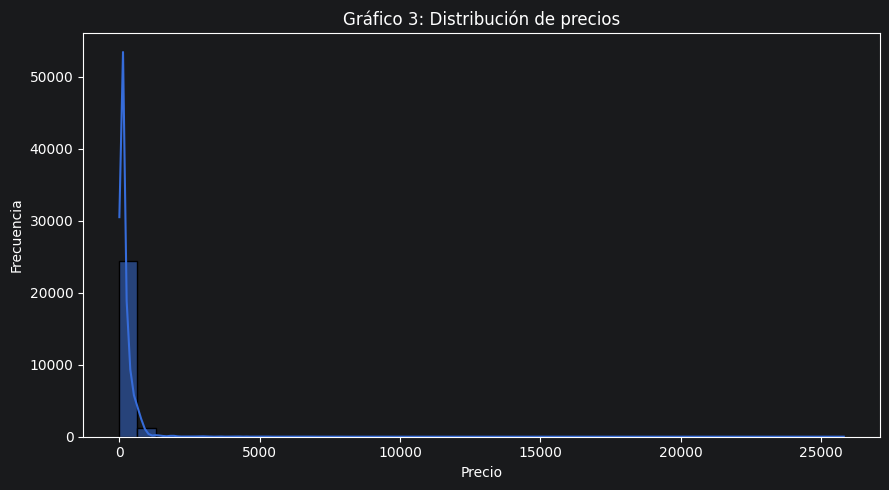

In [8]:
# 6.3 DISTRIBUCIÓN DE LA VARIABLE PRECIO

plt.figure(figsize=(9, 5))

sns.histplot(
    data=datos_limpios,
    x="Precio",
    bins=40,
    kde=True
)

plt.title("Gráfico 3: Distribución de precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [9]:
# 6.4 RESUMEN ESTADÍSTICO DE PRECIO

print("Resumen estadístico de la variable Precio:")
print(datos_limpios["Precio"].describe().round(2))

print("-" * 50)

media_precio = datos_limpios["Precio"].mean()
mediana_precio = datos_limpios["Precio"].median()
precio_minimo = datos_limpios["Precio"].min()
precio_maximo = datos_limpios["Precio"].max()

print(f"Precio promedio: ${media_precio:.2f}")
print(f"Precio mediano: ${mediana_precio:.2f}")
print(f"Precio mínimo: ${precio_minimo:.2f}")
print(f"Precio máximo: ${precio_maximo:.2f}")

Resumen estadístico de la variable Precio:
count    25897.00
mean       238.65
std        504.41
min          6.00
25%         75.00
50%        129.00
75%        249.00
max      25800.00
Name: Precio, dtype: float64
--------------------------------------------------
Precio promedio: $238.65
Precio mediano: $129.00
Precio mínimo: $6.00
Precio máximo: $25800.00


### Interpretación de la variable Precio

La variable `Precio` es la variable numérica principal del análisis.

El histograma permite observar cómo se distribuyen los precios dentro del dataset. En este caso, es esperable encontrar una distribución asimétrica, ya que una base de supermercado puede incluir productos muy baratos y también productos de mayor valor.

La comparación entre media y mediana es importante. Si la media es mayor que la mediana, significa que existen precios altos que elevan el promedio general.

Por ese motivo, la mediana puede representar mejor el precio típico de la base, mientras que la media sirve para entender el comportamiento promedio general.

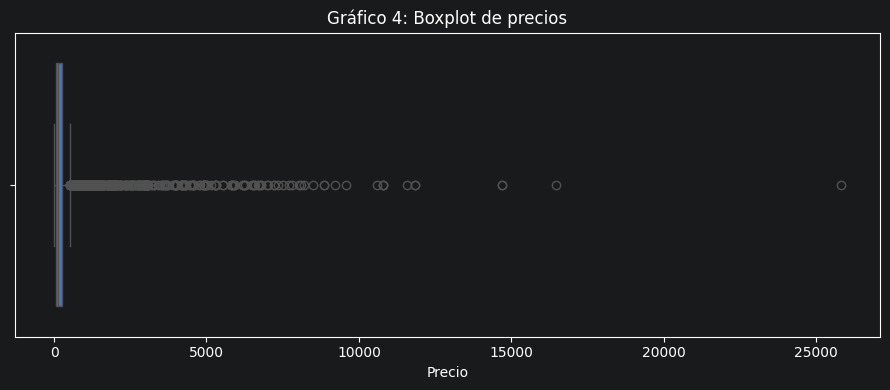

In [10]:
# 6.5 BOXPLOT DE LA VARIABLE PRECIO

plt.figure(figsize=(9, 4))

sns.boxplot(
    data=datos_limpios,
    x="Precio"
)

plt.title("Gráfico 4: Boxplot de precios")
plt.xlabel("Precio")
plt.tight_layout()
plt.show()

### Interpretación del boxplot

El boxplot permite visualizar la dispersión de los precios y detectar valores alejados del rango principal.

En este dataset aparecen valores extremos, lo cual es razonable dentro del contexto comercial. La base puede incluir productos de rubros muy diferentes, por lo que no todos los precios tienen por qué concentrarse en el mismo rango.

Por este motivo, los valores altos no se eliminan automáticamente. Primero se observan y se interpretan dentro del contexto del negocio.

In [11]:
# 6.6 RESUMEN FINAL DEL ANÁLISIS UNIVARIANTE

cantidad_supermercados = datos_limpios["Super"].nunique()
cantidad_grupos = datos_limpios["Grupo"].nunique()
cantidad_productos = datos_limpios["Producto"].nunique()

print("RESUMEN DEL PASO 6")
print("-" * 50)
print(f"Cantidad de supermercados analizados: {cantidad_supermercados}")
print(f"Cantidad de grupos de productos: {cantidad_grupos}")
print(f"Cantidad de productos distintos: {cantidad_productos}")
print(f"Precio promedio: ${media_precio:.2f}")
print(f"Precio mediano: ${mediana_precio:.2f}")
print(f"Precio mínimo: ${precio_minimo:.2f}")
print(f"Precio máximo: ${precio_maximo:.2f}")

RESUMEN DEL PASO 6
--------------------------------------------------
Cantidad de supermercados analizados: 18
Cantidad de grupos de productos: 11
Cantidad de productos distintos: 425
Precio promedio: $238.65
Precio mediano: $129.00
Precio mínimo: $6.00
Precio máximo: $25800.00


### Conclusión del Paso 6

El análisis univariante permitió conocer la estructura básica del dataset limpio.

Se observó la distribución de registros por supermercado, los grupos de productos más frecuentes y el comportamiento general de la variable `Precio`.

La variable `Precio` presenta una dispersión amplia, lo cual es coherente con una base comercial que contiene productos de diferentes rubros. Por esta razón, los valores extremos no se consideran errores de forma automática, sino posibles registros válidos que deberán analizarse con mayor detalle en pasos posteriores.

A partir de este punto, el análisis puede avanzar hacia el estudio de relaciones entre variables, especialmente entre `Super`, `Grupo` y `Precio`.

## Paso 7: Análisis bivariante

En este paso se analiza la relación entre dos o más variables del dataset.

Como la única variable numérica principal es `Precio`, el análisis se centra en estudiar cómo cambia el precio según variables categóricas como `Super` y `Grupo`.

En lugar de utilizar una matriz de correlación tradicional, que no sería útil en este caso por tener una sola variable numérica relevante, se utilizarán agrupaciones, gráficos comparativos y una tabla dinámica comercial.

El objetivo es responder preguntas como:

- ¿Qué supermercados tienen precios promedio más altos?
- ¿Qué grupos de productos presentan mayores precios promedio?
- ¿Cómo varía el precio promedio según la combinación entre supermercado y grupo de producto?

In [12]:
# PASO 7: ANÁLISIS BIVARIANTE

# 7.1 PRECIO PROMEDIO POR SUPERMERCADO

precio_por_super = (
    datos_limpios
    .groupby("Super")["Precio"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
    .round(2)
)

precio_por_super

,count,mean,median,min,max
Super,,,,,
San Roque,398,442.97,257.00,32.0,16480.0
Pigalle,343,429.77,299.00,18.0,8490.0
FarmaGlobal,727,375.40,178.53,10.0,11845.1
Farmashop,755,305.87,175.00,33.0,11570.0
Macro,1713,272.58,133.00,8.0,9570.5
Tienda Inglesa,2137,261.68,134.00,19.0,25800.0
Micro Macro,1534,256.33,134.18,7.0,6210.0
Disco,1921,240.39,129.00,29.0,10790.0
Devoto,1868,239.15,129.00,23.0,7710.0


### Relación entre supermercado y precio

La tabla resume el comportamiento de los precios por supermercado.

Se calcula la cantidad de registros, el precio promedio, la mediana, el mínimo y el máximo para cada cadena.

Esta comparación permite observar diferencias generales entre supermercados. Sin embargo, debe interpretarse con cuidado, ya que un supermercado puede tener más registros de determinados grupos de productos que otro. Por eso, el promedio general no significa necesariamente que una cadena sea siempre más cara o más barata.

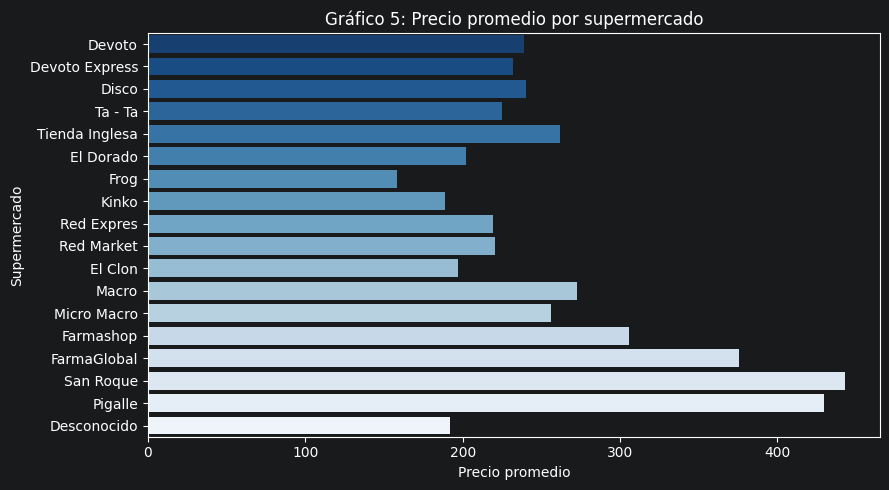

In [13]:
# 7.2 GRÁFICO DE PRECIO PROMEDIO POR SUPERMERCADO

plt.figure(figsize=(9, 5))

sns.barplot(
    data=datos_limpios,
    y="Super",
    x="Precio",
    estimator="mean",
    errorbar=None,
    hue="Super",
    palette="Blues_r",
    legend=False
)

plt.title("Gráfico 5: Precio promedio por supermercado")
plt.xlabel("Precio promedio")
plt.ylabel("Supermercado")
plt.tight_layout()
plt.show()

### Interpretación del gráfico

El gráfico permite comparar visualmente el precio promedio de los productos según el supermercado.

Las diferencias observadas pueden estar relacionadas tanto con la política de precios de cada cadena como con el tipo de productos relevados en cada una.

Por este motivo, el análisis se complementa con una comparación por grupo de producto.

In [14]:
# 7.3 PRECIO PROMEDIO POR GRUPO DE PRODUCTO

precio_por_grupo = (
    datos_limpios
    .groupby("Grupo")["Precio"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
    .round(2)
)

precio_por_grupo.head(10)

,count,mean,median,min,max
Grupo,,,,,
Cuidado personal,6361,384.18,213.0,29.0,25800.0
cuidado personal,1092,356.02,204.0,29.0,11570.0
Alimentos y bebidas,13071,194.02,114.0,21.0,8200.0
alimentos y bebidas,2334,192.92,115.0,21.0,7710.0
limpieza del hogar,280,147.77,94.0,35.0,1990.0
Limpieza del hogar,1484,125.86,89.0,30.0,1643.6
frutas y verduras,157,116.69,109.0,32.0,1430.0
Frutas y verduras,919,116.17,99.0,27.0,1469.0
Establecimientos Relevados,22,73.27,25.5,6.0,590.0


### Relación entre grupo de producto y precio

Esta tabla permite identificar qué grupos de productos presentan precios promedio más altos.

El análisis por grupo es importante porque los precios no dependen únicamente del supermercado, sino también del tipo de producto vendido.

En una base comercial amplia, es esperable que algunos rubros tengan precios naturalmente más elevados que otros.

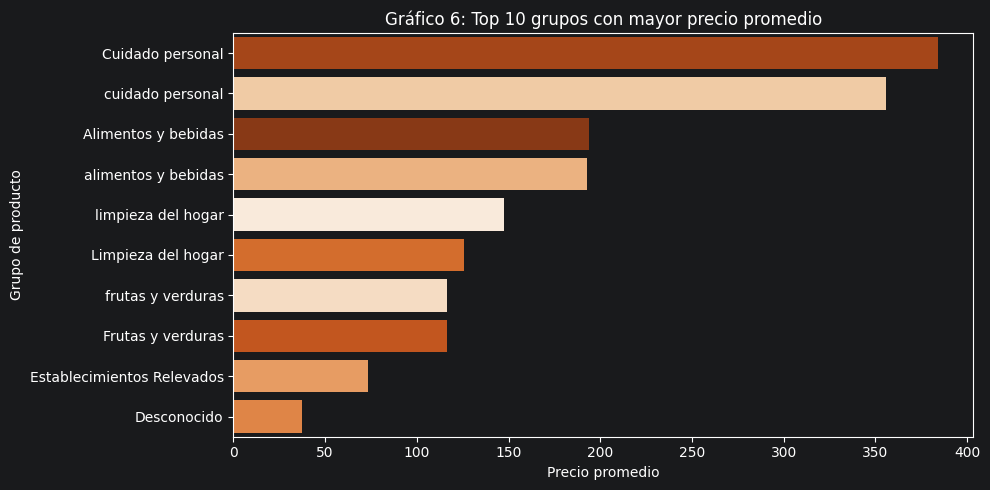

In [15]:
# 7.4 TOP 10 GRUPOS CON MAYOR PRECIO PROMEDIO

top_grupos_precio = precio_por_grupo.head(10).index

plt.figure(figsize=(10, 5))

sns.barplot(
    data=datos_limpios[datos_limpios["Grupo"].isin(top_grupos_precio)],
    y="Grupo",
    x="Precio",
    estimator="mean",
    errorbar=None,
    hue="Grupo",
    palette="Oranges_r",
    legend=False,
    order=top_grupos_precio
)

plt.title("Gráfico 6: Top 10 grupos con mayor precio promedio")
plt.xlabel("Precio promedio")
plt.ylabel("Grupo de producto")
plt.tight_layout()
plt.show()

### Interpretación del precio por grupo

El gráfico muestra los grupos de productos con mayor precio promedio.

Esta visualización ayuda a explicar por qué existen valores altos dentro del dataset. Los precios elevados pueden no ser errores, sino registros correspondientes a rubros naturalmente más caros.

Por eso, antes de eliminar valores extremos, es necesario entender a qué grupos pertenecen.

In [16]:
# 7.5 TABLA DINÁMICA: SUPERMERCADO VS GRUPO

matriz_precios = datos_limpios.pivot_table(
    values="Precio",
    index="Super",
    columns="Grupo",
    aggfunc="mean"
)

matriz_precios = matriz_precios.round(2)

matriz_precios

Grupo,Alimentos y bebidas,Cuidado personal,Desconocido,Establecimientos Relevados,Familia,Frutas y verduras,Limpieza del hogar,alimentos y bebidas,cuidado personal,frutas y verduras,limpieza del hogar
Super,,,,,,,,,,,
Desconocido,159.57,295.35,26.00,24.67,23.0,102.60,105.94,166.38,270.99,112.60,119.07
Devoto,216.22,354.78,23.00,23.00,23.0,119.17,106.32,249.72,369.57,187.67,154.95
Devoto Express,204.62,371.42,36.00,36.00,36.0,104.38,139.07,NaN,NaN,NaN,NaN
Disco,192.80,400.67,58.22,165.00,29.0,117.67,115.72,211.43,559.93,156.19,284.83
El Clon,151.49,300.71,16.00,16.00,16.0,NaN,152.38,195.50,252.30,NaN,198.67
El Dorado,139.07,394.51,71.22,75.00,68.0,NaN,117.29,176.75,278.15,NaN,103.10
FarmaGlobal,272.49,455.46,10.00,10.00,10.0,NaN,136.84,179.72,307.48,NaN,124.76
Farmashop,166.76,383.94,161.12,173.00,157.0,NaN,134.74,137.31,538.62,NaN,103.31
Frog,158.36,202.22,22.00,22.00,22.0,NaN,79.27,171.69,163.00,NaN,67.44


### Tabla dinámica comercial

La tabla dinámica cruza supermercados con grupos de productos.

Cada celda representa el precio promedio de un grupo específico dentro de un supermercado determinado.

Este análisis es más útil que una correlación tradicional porque permite estudiar una relación comercial concreta: cómo varía el precio promedio según la combinación entre cadena y rubro.

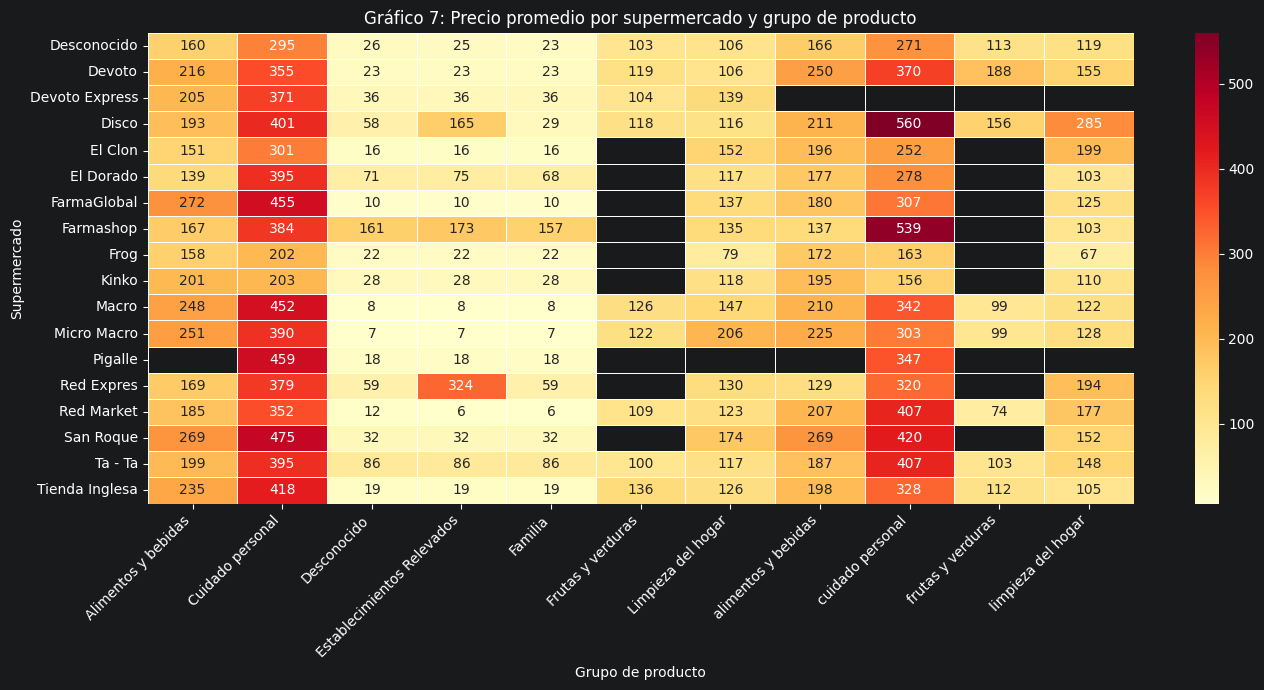

In [17]:
# 7.6 MAPA DE CALOR DE PRECIOS PROMEDIO

plt.figure(figsize=(14, 7))

sns.heatmap(
    matriz_precios,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Gráfico 7: Precio promedio por supermercado y grupo de producto")
plt.xlabel("Grupo de producto")
plt.ylabel("Supermercado")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretación del mapa de calor

El mapa de calor permite detectar rápidamente diferencias de precio promedio entre supermercados y grupos de productos.

Los colores más intensos representan precios promedio más altos, mientras que los colores más claros representan precios promedio más bajos.

Esta visualización permite identificar combinaciones específicas donde los precios son más elevados o más bajos. Además, permite observar si las diferencias parecen depender más del supermercado, del grupo de producto o de la combinación entre ambos.

In [18]:
# 7.7 INSIGHTS AUTOMÁTICOS DEL ANÁLISIS BIVARIANTE

# Convertimos la matriz a formato largo para facilitar la búsqueda de máximos y mínimos
matriz_larga = matriz_precios.stack()

combinacion_maxima = matriz_larga.idxmax()
valor_maximo = matriz_larga.max()

combinacion_minima = matriz_larga.idxmin()
valor_minimo = matriz_larga.min()

print("INSIGHTS DEL ANÁLISIS BIVARIANTE")
print("-" * 50)
print(
    f"Mayor precio promedio: {combinacion_maxima[0]} - {combinacion_maxima[1]} "
    f"con un promedio de ${valor_maximo:.2f}"
)
print(
    f"Menor precio promedio: {combinacion_minima[0]} - {combinacion_minima[1]} "
    f"con un promedio de ${valor_minimo:.2f}"
)

INSIGHTS DEL ANÁLISIS BIVARIANTE
--------------------------------------------------
Mayor precio promedio: Disco - cuidado personal con un promedio de $559.93
Menor precio promedio: Red Market - Establecimientos Relevados con un promedio de $6.00


## Paso 8: Análisis de valores atípicos

En este paso se analizan los valores atípicos de la variable `Precio`.

Un valor atípico es un dato que se encuentra muy alejado del comportamiento general de la variable. En muchos casos puede representar un error de carga, pero en este dataset comercial también puede representar productos reales de mayor valor.

Por ese motivo, no se eliminarán automáticamente los valores extremos. Primero se analizará su comportamiento para decidir si tienen sentido dentro del contexto del negocio.

In [19]:
# PASO 8: ANÁLISIS DE VALORES ATÍPICOS

# 8.1 DETECCIÓN DE VALORES ATÍPICOS CON EL MÉTODO IQR


# Calculamos el primer cuartil, tercer cuartil y rango intercuartílico
q1 = datos_limpios["Precio"].quantile(0.25)
q3 = datos_limpios["Precio"].quantile(0.75)
iqr = q3 - q1

# Definimos los límites inferior y superior
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

# Filtramos los posibles valores atípicos
outliers_precio = datos_limpios[
    (datos_limpios["Precio"] < limite_inferior) |
    (datos_limpios["Precio"] > limite_superior)
    ]

print("ANÁLISIS DE VALORES ATÍPICOS")
print("-" * 50)
print(f"Primer cuartil Q1: ${q1:.2f}")
print(f"Tercer cuartil Q3: ${q3:.2f}")
print(f"Rango intercuartílico IQR: ${iqr:.2f}")
print(f"Límite inferior: ${limite_inferior:.2f}")
print(f"Límite superior: ${limite_superior:.2f}")
print("-" * 50)
print(f"Cantidad de posibles outliers: {outliers_precio.shape[0]}")
print(f"Porcentaje de outliers: {(outliers_precio.shape[0] / datos_limpios.shape[0]) * 100:.2f}%")

ANÁLISIS DE VALORES ATÍPICOS
--------------------------------------------------
Primer cuartil Q1: $75.00
Tercer cuartil Q3: $249.00
Rango intercuartílico IQR: $174.00
Límite inferior: $-186.00
Límite superior: $510.00
--------------------------------------------------
Cantidad de posibles outliers: 2471
Porcentaje de outliers: 9.54%


### Método utilizado para detectar outliers

Para detectar posibles valores atípicos se utiliza el método del rango intercuartílico, conocido como IQR.

Este método calcula la distancia entre el primer cuartil y el tercer cuartil. Luego define un límite superior e inferior. Los valores que quedan fuera de esos límites se consideran posibles outliers.

Sin embargo, que un valor sea marcado como outlier estadístico no significa necesariamente que sea un error. En este caso, puede tratarse de productos reales con precios altos.

In [27]:
# 8.2 PRODUCTOS CON PRECIOS MÁS ALTOS

productos_mas_caros = (
    datos_limpios
    .sort_values("Precio", ascending=False)
    [["Periodo", "Super", "Grupo", "Producto", "Precio"]]
    .head(20)
)

productos_mas_caros

,Periodo,Super,Grupo,Producto,Precio
26729,Feb25,Tienda Inglesa,Cuidado personal,Protector solar SPF 50 Eucerin 150 ml.,25800.0
26246,Abr25,San Roque,Cuidado personal,Protector solar SPF 40 Dermaglós 250 ml.,16480.0
26718,Oct25,El Dorado,Cuidado personal,"Crema Facial Revitalift Filler Dia, 50 ml.",14690.0
26348,Mar25,El Dorado,Cuidado personal,"Crema Facial Revitalift Filler Dia, 50 ml.",14690.0
26833,Abr25,FarmaGlobal,Cuidado personal,"Pañales Babysec Premium Extra Extra Grande, 48...",11845.1
26510,Sep25,FarmaGlobal,Cuidado personal,"Pañales Babysec Premium Extra Extra Grande, 48...",11845.1
26444,Jun25,Farmashop,cuidado personal,panales para ninos comun Babysec (48 unidades),11570.0
26480,Jun25,Disco,cuidado personal,panales para ninos comun Babysec (48 unidades),10790.0
26391,Abr25,Ta - Ta,Cuidado personal,"Pañales Babysec Premium Extra Extra Grande, 48...",10790.0
26629,Feb25,Ta - Ta,Cuidado personal,"Pañales Babysec Premium Extra Extra Grande, 48...",10790.0


### Revisión de los precios más altos

Se revisan los productos con precios más altos para comprender si los valores extremos pueden tener sentido dentro del contexto comercial.

Esta revisión es importante porque permite diferenciar entre posibles errores de carga y productos que realmente pueden tener precios más elevados.

En un supermercado pueden existir productos de rubros muy distintos, por lo que no corresponde eliminar automáticamente los valores altos solo por estar alejados del promedio.

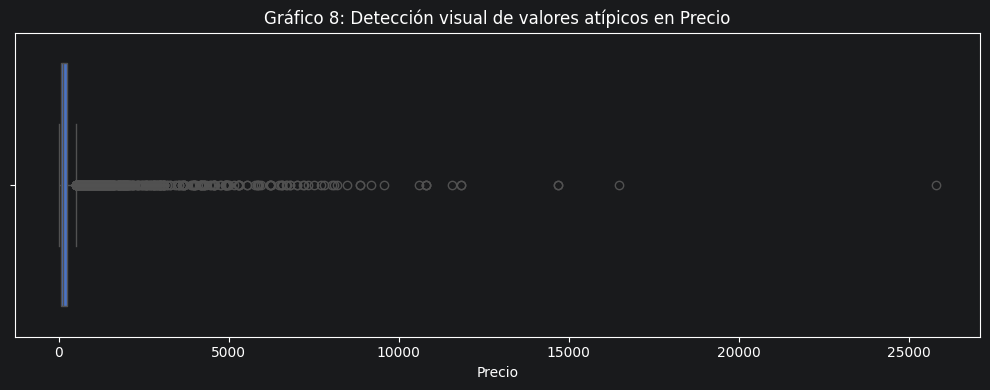

In [21]:
# 8.3 VISUALIZACIÓN GENERAL DE OUTLIERS

plt.figure(figsize=(10, 4))

sns.boxplot(
    data=datos_limpios,
    x="Precio"
)

plt.title("Gráfico 8: Detección visual de valores atípicos en Precio")
plt.xlabel("Precio")
plt.tight_layout()
plt.show()

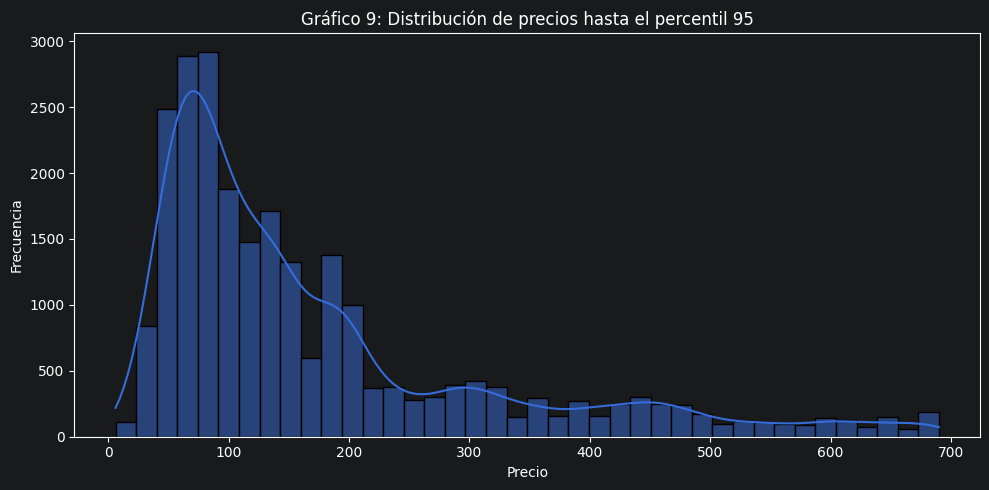

Percentil 95 de Precio: $690.00
Registros incluidos en esta visualización: 24615


In [22]:
# 8.4 DISTRIBUCIÓN DE PRECIOS SIN EXTREMOS VISUALES

# Para visualizar mejor la concentración principal de precios,
# se grafica solo hasta el percentil 95.
percentil_95 = datos_limpios["Precio"].quantile(0.95)

datos_hasta_p95 = datos_limpios[datos_limpios["Precio"] <= percentil_95]

plt.figure(figsize=(10, 5))

sns.histplot(
    data=datos_hasta_p95,
    x="Precio",
    bins=40,
    kde=True
)

plt.title("Gráfico 9: Distribución de precios hasta el percentil 95")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(f"Percentil 95 de Precio: ${percentil_95:.2f}")
print(f"Registros incluidos en esta visualización: {datos_hasta_p95.shape[0]}")

### Visualización sin extremos superiores

Para observar mejor la distribución principal de los precios, se genera un histograma limitado hasta el percentil 95.

Esto no significa que se eliminen datos del dataset. La limitación se realiza únicamente para mejorar la visualización, ya que los valores extremadamente altos pueden comprimir el gráfico y dificultar la lectura de la mayoría de los registros.

La base completa se conserva para los análisis posteriores.

In [23]:
# 8.5 DECISIÓN FINAL SOBRE VALORES ATÍPICOS

print("DECISIÓN SOBRE OUTLIERS")
print("-" * 50)
print("Los valores atípicos detectados en Precio no serán eliminados automáticamente.")
print("Motivo: en el contexto comercial, precios altos pueden corresponder a productos reales.")
print("Se conserva el dataset completo para no perder información relevante del negocio.")
print("-" * 50)
print(f"Filas conservadas en datos_limpios: {datos_limpios.shape[0]}")
print(f"Columnas conservadas en datos_limpios: {datos_limpios.shape[1]}")

DECISIÓN SOBRE OUTLIERS
--------------------------------------------------
Los valores atípicos detectados en Precio no serán eliminados automáticamente.
Motivo: en el contexto comercial, precios altos pueden corresponder a productos reales.
Se conserva el dataset completo para no perder información relevante del negocio.
--------------------------------------------------
Filas conservadas en datos_limpios: 25897
Columnas conservadas en datos_limpios: 5


### Conclusión del Paso 8

El análisis de valores atípicos muestra que la variable `Precio` presenta registros alejados del rango principal de la distribución.

Sin embargo, estos valores no se eliminan automáticamente porque pueden representar productos reales de mayor precio. En una base comercial de supermercados es esperable encontrar diferencias importantes entre productos básicos y productos de rubros más costosos.

Por lo tanto, se decide conservar los outliers en el dataset limpio. Esta decisión permite mantener la integridad comercial de la base y evitar la pérdida de información relevante.

## Paso 9: Conclusiones generales del análisis exploratorio

A partir del análisis exploratorio realizado, se pueden extraer las siguientes conclusiones:

1. El dataset contiene información comercial relevante sobre precios de productos en distintas cadenas de supermercados de Uruguay.

2. La variable principal del análisis es `Precio`, mientras que `Super`, `Grupo`, `Producto` y `Periodo` permiten contextualizar cada registro.

3. Durante la limpieza fue necesario convertir la columna `Precio` a formato numérico, ya que originalmente estaba almacenada como texto con coma decimal.

4. Se eliminaron los registros sin precio válido, porque el precio es la variable central del análisis y no corresponde reemplazarlo por valores inventados.

5. Las variables categóricas con valores faltantes fueron completadas con `"Desconocido"` para conservar la mayor cantidad posible de registros útiles.

6. El análisis univariante permitió observar la distribución de supermercados, grupos de productos y precios.

7. El análisis bivariante mostró que los precios varían tanto según el supermercado como según el grupo de producto.

8. La tabla dinámica y el mapa de calor resultaron herramientas adecuadas para analizar la relación entre `Super`, `Grupo` y `Precio`.

9. Los valores atípicos detectados en `Precio` no se eliminaron, ya que pueden representar productos reales de mayor valor dentro del contexto comercial.

En conclusión, el dataset queda preparado para ser utilizado en una aplicación interactiva de Streamlit, donde se podrán visualizar los principales indicadores y relaciones comerciales de forma dinámica.

## Paso 10: Exportación del dataset limpio

Una vez finalizado el análisis exploratorio, se exporta el dataset limpio a un archivo CSV.

Este archivo será utilizado posteriormente por `app.py`, que leerá la base procesada para construir la aplicación web interactiva en Streamlit.

De esta forma, el notebook `practice.ipynb` cumple el rol de informe y preparación de datos, mientras que `app.py` cumple el rol de script para la visualización web.

In [26]:
# PASO 10: EXPORTACIÓN DEL DATASET LIMPIO

# Ruta de salida del archivo limpio
ruta_salida = r"C:\Users\aleva\OneDrive\Escritorio\Alexia\pyhton\data\processed\p4ds_cadenas_limpio._2025.csv"

# Exportamos el dataset limpio
datos_limpios.to_csv(ruta_salida, index=False)

print("Dataset limpio exportado correctamente.")
print("-" * 50)
print("Ruta de salida:")
print(ruta_salida)
print("-" * 50)
print("Dimensiones del archivo exportado:")
print(datos_limpios.shape)

Dataset limpio exportado correctamente.
--------------------------------------------------
Ruta de salida:
C:\Users\aleva\OneDrive\Escritorio\Alexia\pyhton\data\processed\p4ds_cadenas_limpio._2025.csv
--------------------------------------------------
Dimensiones del archivo exportado:
(25897, 5)


### Cierre del notebook

El archivo limpio fue exportado correctamente en formato CSV.

Este archivo constituye la salida final del proceso de limpieza y análisis exploratorio realizado en el notebook. A partir de él se puede alimentar la aplicación desarrollada en Streamlit, manteniendo separados los objetivos de ambos archivos:

- `practice.ipynb`: informe, exploración, limpieza y conclusiones.
- `app.py`: lectura del CSV limpio y construcción de visualizaciones interactivas.